In [3]:
import jax
import jax.numpy as jnp
from matplotlib import pyplot as plt
import pandas as pd

import sys
import os
import importlib
current_dir = os.path.abspath('')
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

import util
importlib.reload(util)

jax.config.update("jax_enable_x64", True)

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [5]:
''' Parameters '''
rho_dm = 0.025
rho_dm_SHM = 0.008
rhos = jnp.array([0.021, 0.016, 0.012, 0.0009, 0.0006, 0.0031, 0.0015, 0.0020, 0.0022, 0.007, 0.0135, 0.006, 0.002, 0.0035, 0.0001])
sigmas = jnp.array([4., 7., 9., 40., 20., 7.5, 10.5, 14., 18., 18.5, 18.5, 20., 20., 37., 100.])
erhos = jnp.array([0.5, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]) * rhos
esigmas = jnp.array([1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 5., 5., 5., 10.])
params = jnp.column_stack((rhos, sigmas))

''' Domain'''
z1 = 1800.
z2 = 0.
n = int(z1/10+1)
poly = (0,0)
n_bins = 20

''' Forward Model '''
uz, zs = util.diffraxDopri5(rho_dm, params, z1, n)
vdfo_norm_calc, z = util.vdfo_norm(z2, z1, zs, uz, n, poly, mock=True)
integral, z_borders = util.binning(vdfo_norm_calc, z, z2, z1, n, n_bins)

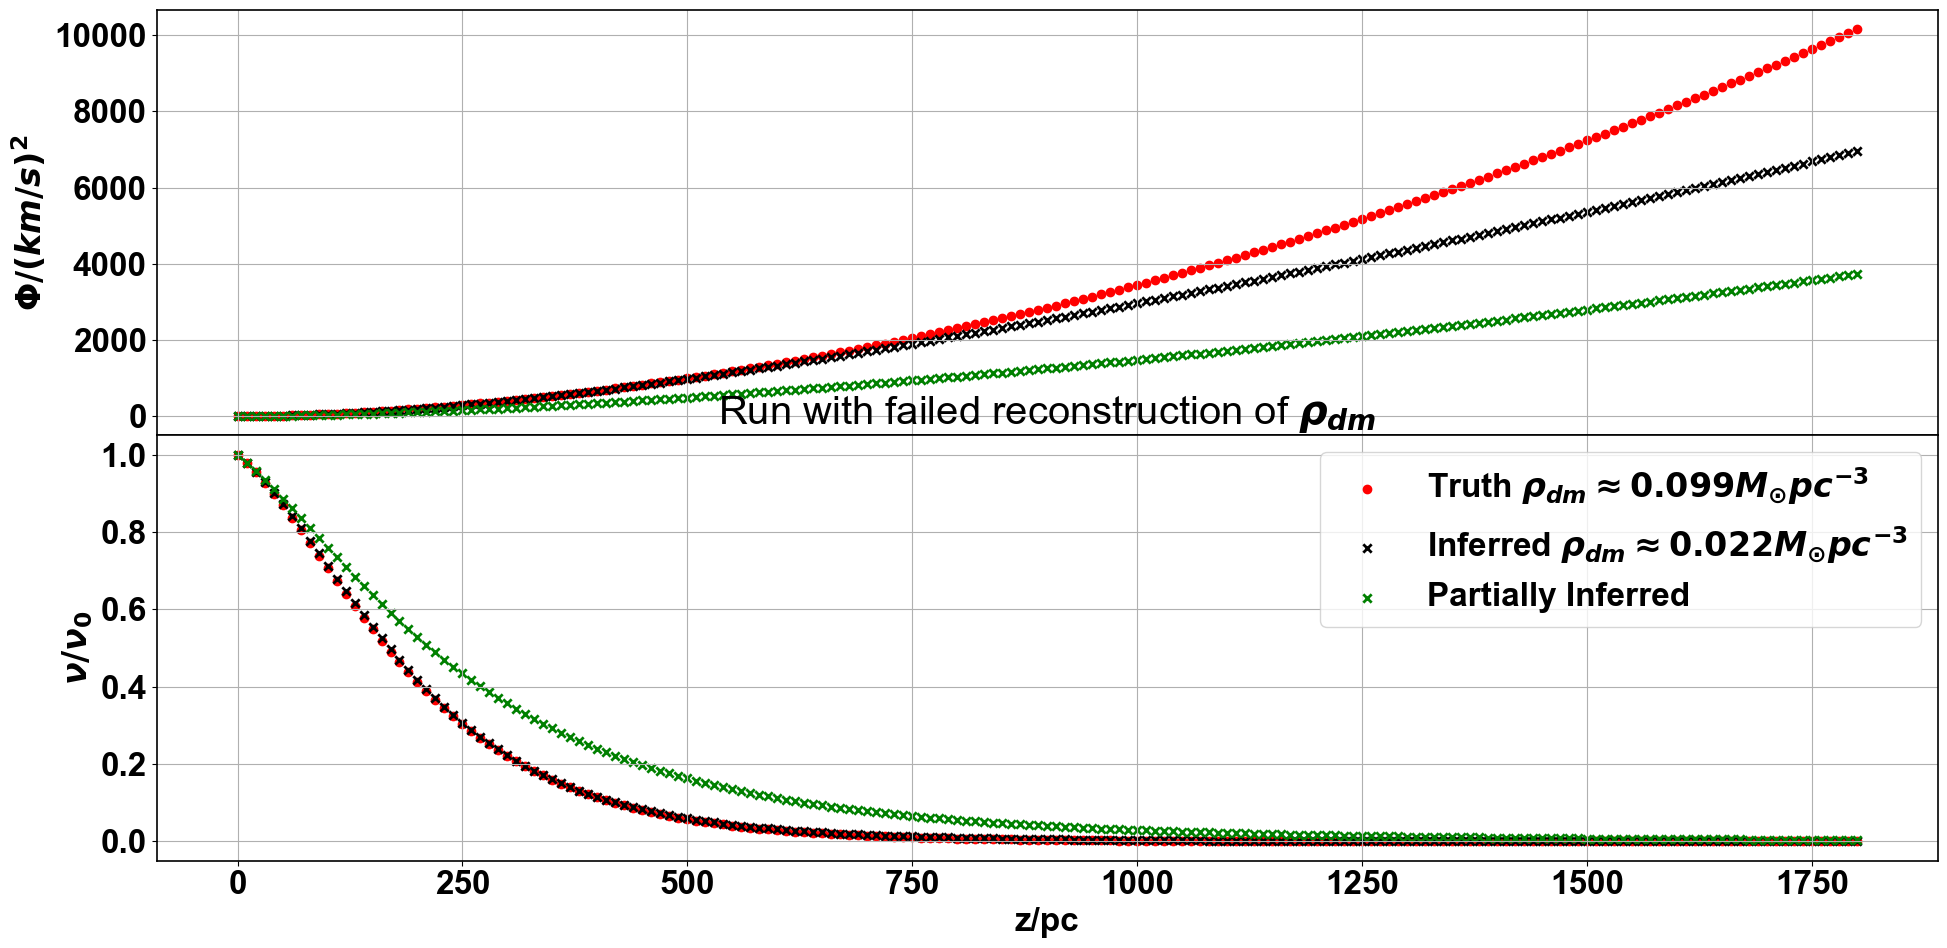

In [8]:
''' Failed reconstruction '''
rho_dm_truth = pd.read_csv('../Tests/finale tests/rhodm_vdfo.csv', header=None).iloc[51,0]
rho_dm_inferred = pd.read_csv('../Tests/finale tests/rhodm_vdfo.csv', header=None).iloc[51,1]
rho_dm_std = pd.read_csv('../Tests/finale tests/rhodm_vdfo.csv', header=None).iloc[51,2]

rho_truth = pd.read_csv('../Tests/finale tests/rhos_vdfo.csv', header=None).iloc[51*15:52*15,0]
rho_inferred = pd.read_csv('../Tests/finale tests/rhos_vdfo.csv', header=None).iloc[51*15:52*15,1]
rho_std = pd.read_csv('../Tests/finale tests/rhos_vdfo.csv', header=None).iloc[51*15:52*15,2]

sigma_truth = pd.read_csv('../Tests/finale tests/sigma_vdfo.csv', header=None).iloc[51*15:52*15,0]
sigma_inferred = pd.read_csv('../Tests/finale tests/sigma_vdfo.csv', header=None).iloc[51*15:52*15,1]
sigma_std = pd.read_csv('../Tests/finale tests/sigma_vdfo.csv', header=None).iloc[51*15:52*15,2]

params_truth = jnp.transpose(jnp.vstack((jnp.array(rho_truth.to_numpy()), jnp.array(sigma_truth.to_numpy()))))
params_inferred = jnp.transpose(jnp.vstack((jnp.array(rho_inferred.to_numpy()), jnp.array(sigma_inferred.to_numpy()))))

uz_truth, zs_truth = util.diffraxDopri5(rho_dm_truth, params_truth, z1, n)
vdfo_norm_calc_truth, z_truth = util.vdfo_norm(z2, z1, zs_truth, uz_truth, n, poly, mock=True)
uz_inferred, zs_inferred = util.diffraxDopri5(rho_dm_inferred, params_inferred, z1, n)
vdfo_norm_calc_inferred, z_inferred = util.vdfo_norm(z2, z1, zs_inferred, uz_inferred, n, poly, mock=True)

uz_partial_truth, zs_partial_truth = util.diffraxDopri5(rho_dm_truth, params, z1, n)
vdfo_norm_calc_partial_truth, z_partial_truth = util.vdfo_norm(z2, z1, zs_partial_truth, uz_partial_truth, n, poly, mock=True)
uz_partial_inferred, zs_partial_inferred = util.diffraxDopri5(rho_dm_inferred, params, z1, n)
vdfo_norm_calc_partial_inferred, z_partial_inferred = util.vdfo_norm(z2, z1, zs_partial_inferred, uz_partial_inferred, n, poly, mock=True)

''' Visualisierung fail'''
fig, ax = plt.subplots(2, 1, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [1,1]})
plt.title('Run with failed reconstruction of $\\rho_{dm}$')
ax[0].set_xlabel('z/pc')
ax[0].set_ylabel('$\Phi / (km/s)^2$')
ax[0].scatter(zs_truth, [u[0] for u in uz_truth], marker='o', color='red', label=rf'Truth $\rho_{{dm}} \approx {rho_dm_truth:.3f}$')
ax[0].scatter(zs_inferred, [u[0] for u in uz_inferred], marker='x', color='black', label=rf'Inferred $\rho_{{dm}} \approx {rho_dm_inferred:.3f}$')
# ax[0].scatter(zs_partial_truth, [u[0] for u in uz_partial_truth], marker='o', color='blue', label='Partially Truth')
ax[0].scatter(zs_partial_inferred, [u[0] for u in uz_partial_inferred], marker='x', color='green', label='Partially Inferred')
ax[0].grid()
ax[1].set_xlabel('z/pc')
ax[1].set_ylabel('$\\nu / \\nu_0 $')
ax[1].scatter(z_truth, vdfo_norm_calc_truth, marker='o', color='red', label=rf'Truth $\rho_{{dm}} \approx {rho_dm_truth:.3f}M_{{\odot}}pc^{{{-3}}}$')
ax[1].scatter(z_inferred, vdfo_norm_calc_inferred, marker='x', color='black', label=rf'Inferred $\rho_{{dm}} \approx {rho_dm_inferred:.3f}M_{{\odot}}pc^{{{-3}}}$')
# ax[1].scatter(z_partial_truth, vdfo_norm_calc_partial_truth, marker='o', color='blue', label='Partially Truth')
ax[1].scatter(z_partial_inferred, vdfo_norm_calc_partial_inferred, marker='x', color='green', label='Partially Inferred')
ax[1].grid()
ax[1].legend()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('../Plots/failed_reconstruction.png')

In [7]:
''' Influence of Parameters '''
# rhos_dm = jnp.unique(jnp.concatenate((jnp.round(jnp.linspace(0., 0.2, 11), decimals = 3), jnp.round(jnp.linspace(0.005, 0.03, 6), decimals=3))))
rhos_dm = jnp.round(jnp.linspace(0., 0.03, 7), decimals=3)

params_pp = params + jnp.transpose(jnp.vstack((erhos, esigmas)))
params_pm = params + jnp.transpose(jnp.vstack((erhos, -esigmas)))
params_mp = params + jnp.transpose(jnp.vstack((-erhos, esigmas)))
params_mm = params + jnp.transpose(jnp.vstack((-erhos, -esigmas)))

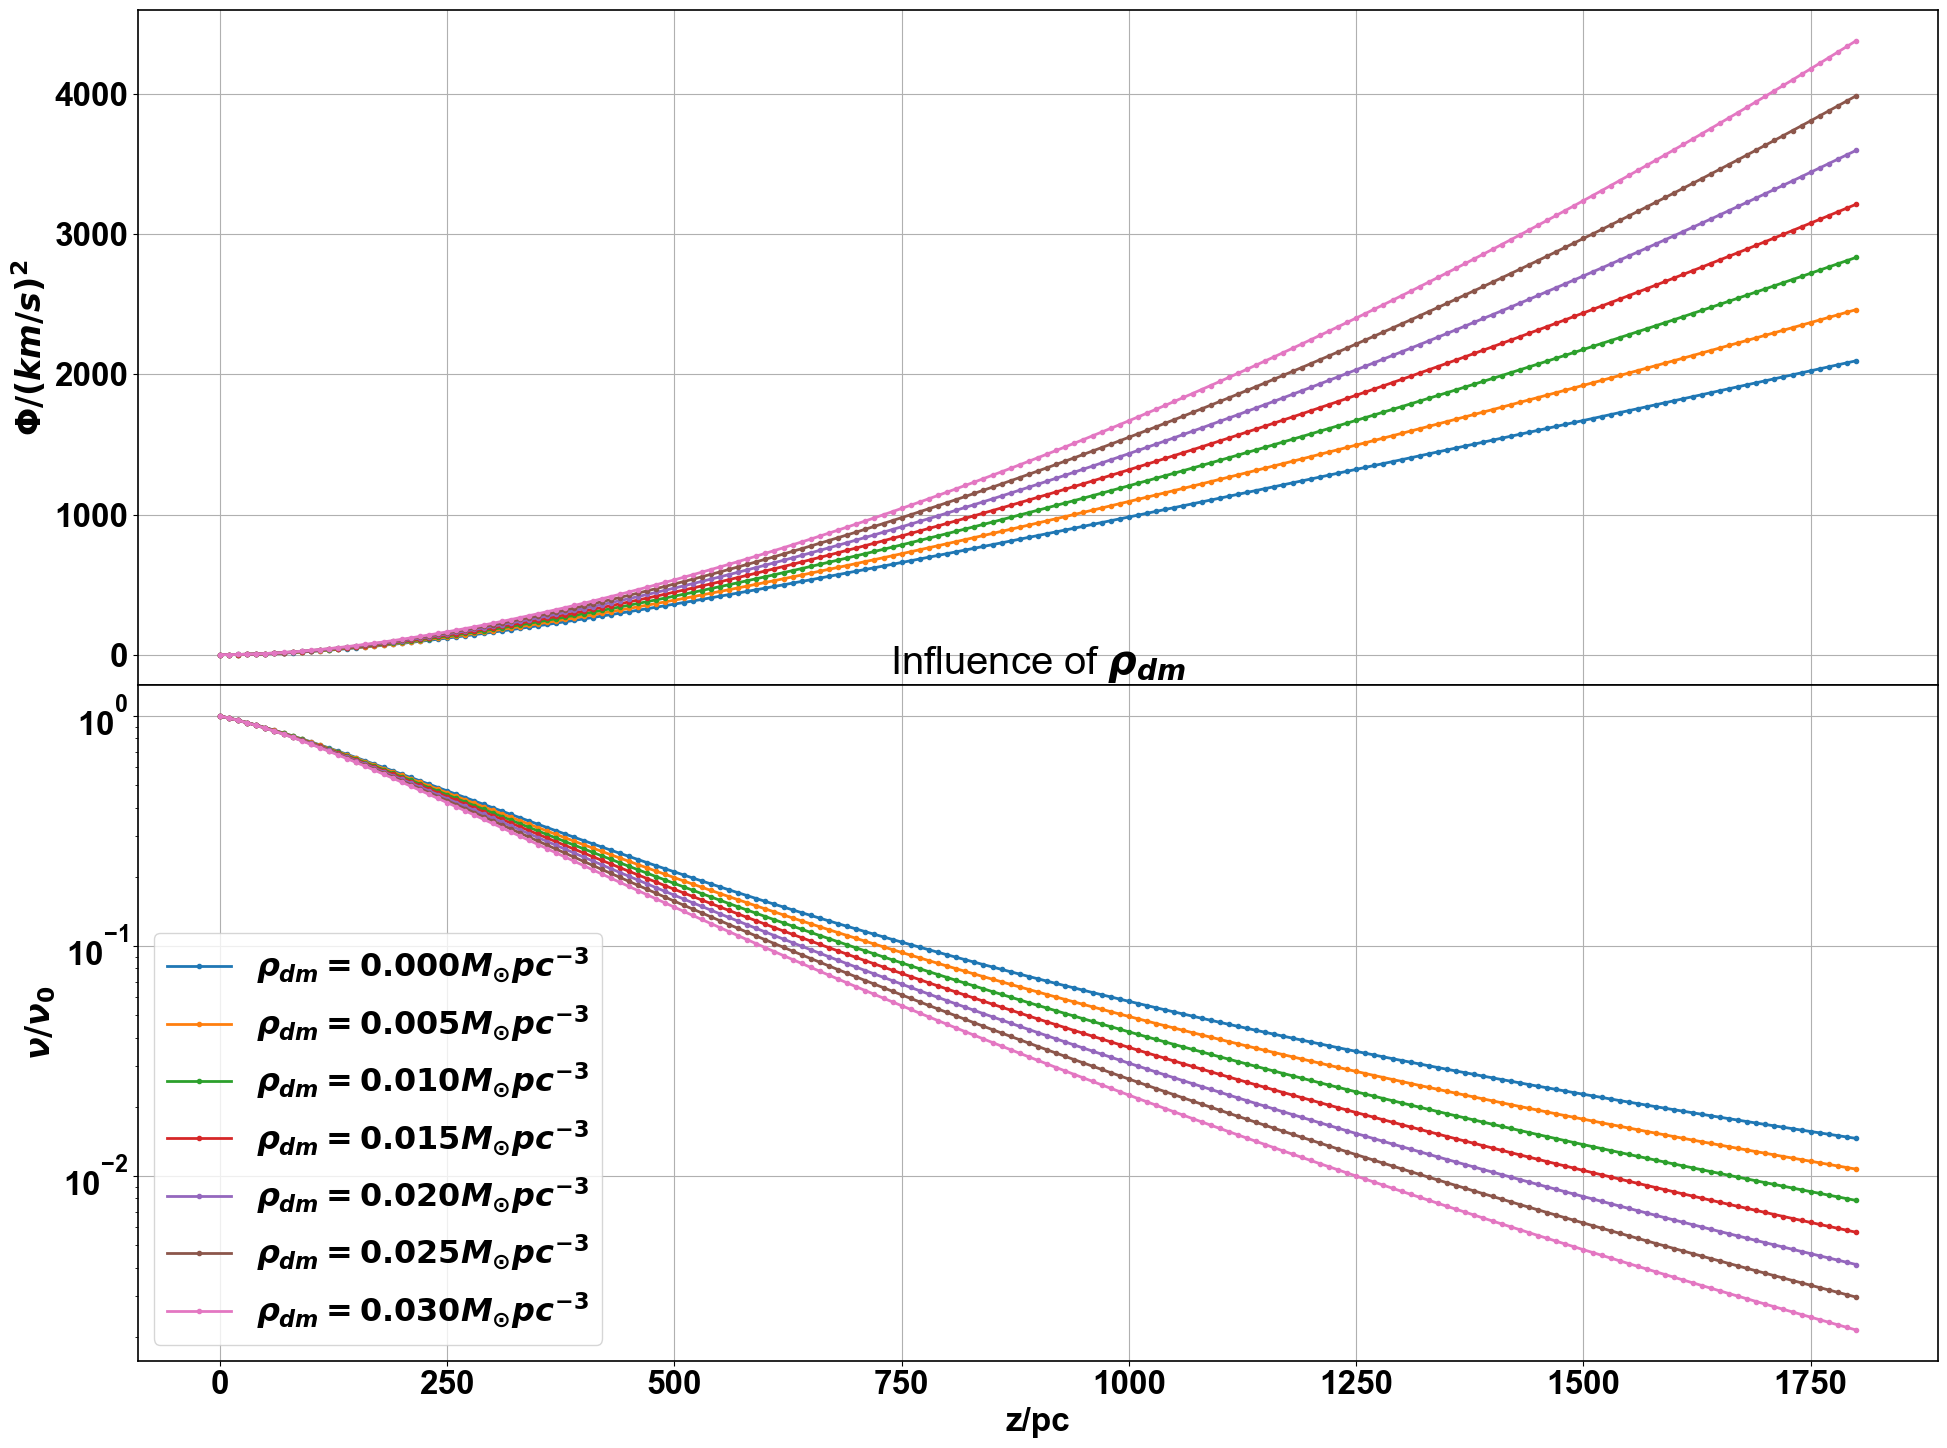

In [9]:

''' Visualisierung rho_dm first'''
fig, ax = plt.subplots(2, figsize=(20,15), sharex=True, gridspec_kw={'height_ratios': [1,1]})
plt.title('Influence of $\\rho_{dm}$')
ax[0].set_xlabel('z/pc')
ax[0].set_ylabel('$\Phi / (km/s)^2$')
ax[1].set_xlabel('z/pc')
ax[1].set_ylabel('$\\nu / \\nu_0 $')
ax[1].set_yscale('log')

for rd in rhos_dm:
    uz, zs = util.diffraxDopri5(rd, params, z1, n)
    vdfo_norm_calc, z = util.vdfo_norm(z2, z1, zs, uz, n, poly, mock=True)
    ax[0].plot(zs, [u[0] for u in uz], label=rf'$\rho_{{dm}} = {rd:.3f}M_{{\odot}}pc^{{{-3}}}', marker='.')
    ax[1].plot(z, vdfo_norm_calc, label=rf'$\rho_{{dm}} = {rd:.3f}M_{{\odot}}pc^{{{-3}}}$', marker='.')

ax[0].grid()
ax[1].grid()
ax[1].legend(prop={'size': 23})
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('../Plots/influence_rho_dm.png')

# ''' Visualisierung rho_dm norm'''
# fig, ax = plt.subplots(2, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Influence of $\\rho_{dm}$')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('$\Phi / (km/s)^2$')
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel('$\\nu / \\nu_0 $')
# ax[1].set_yscale('log')

# for rho_dm in rhos_dm:
#     uz, zs = util.diffraxDopri5(rho_dm, params, z1, n)
#     vdfo_norm_calc, z = util.vdfo_norm(z2, z1, zs, uz, n, poly, mock=True)
#     ax[0].scatter(zs, [u[0] for u in uz], label=f'$\\rho_dm = {rho_dm:.3f}$')
#     ax[1].scatter(z, vdfo_norm_calc/jnp.sum(vdfo_norm_calc), label=f'$\\rho_dm = {rho_dm:.3f}$')

# ax[0].grid()
# ax[1].grid()
# ax[1].legend(prop={'size': 23})
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

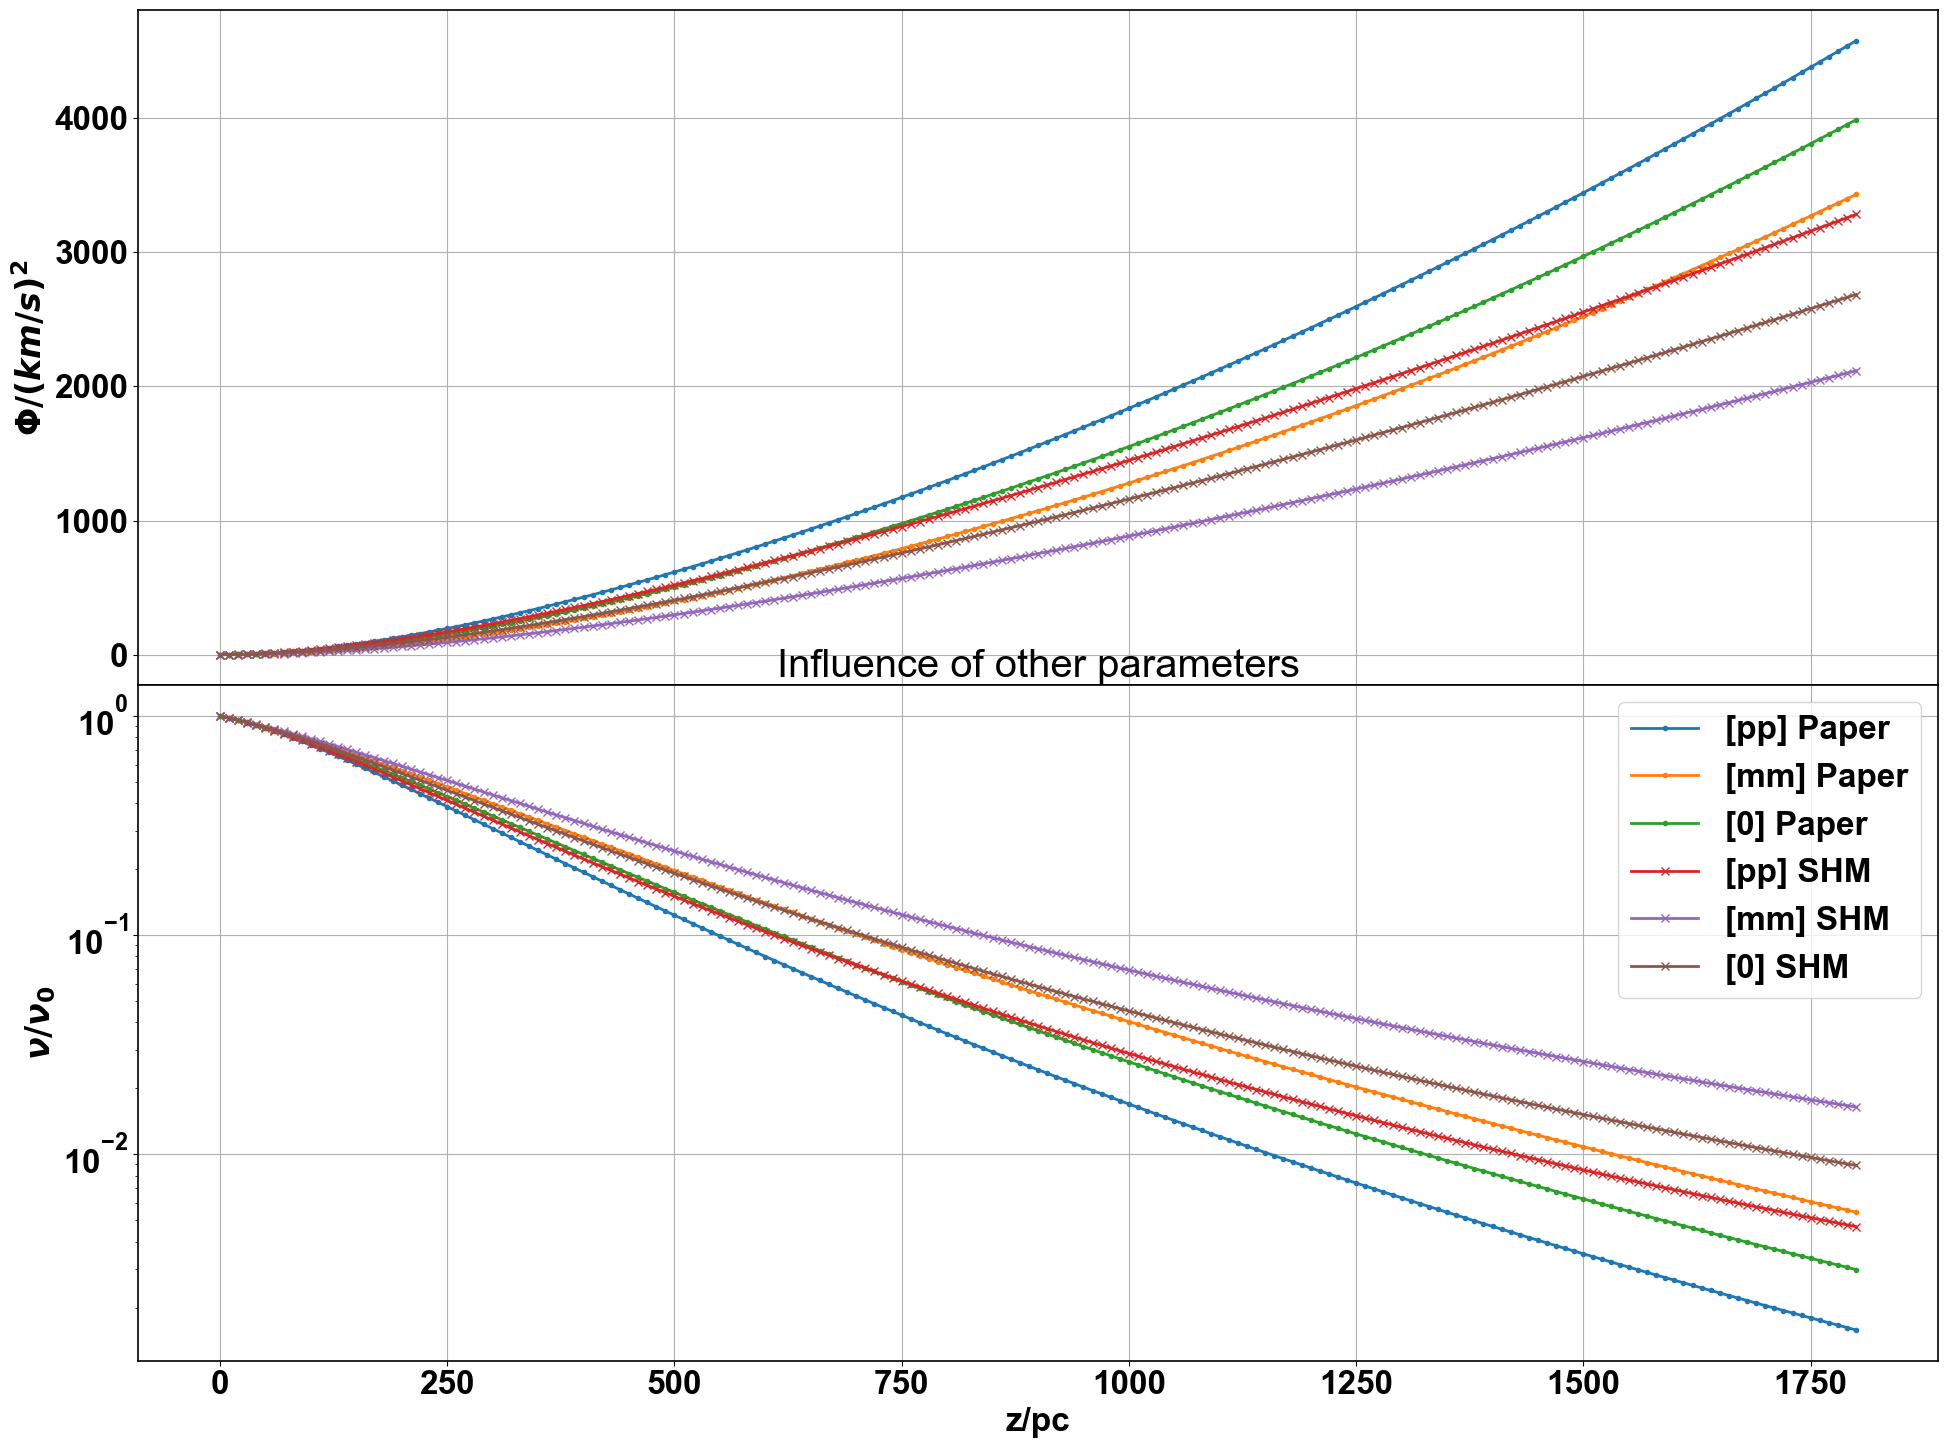

In [10]:
''' Visualisierung other params'''
fig, ax = plt.subplots(2, figsize=(20,15), sharex=True, gridspec_kw={'height_ratios': [1,1]})
plt.title('Influence of other parameters')
ax[0].set_xlabel('z/pc')
ax[0].set_ylabel('$\Phi / (km/s)^2$')
ax[1].set_xlabel('z/pc')
ax[1].set_ylabel('$\\nu / \\nu_0 $')
ax[1].set_yscale('log')
for rd, lab, mark in zip([rho_dm, rho_dm_SHM], ['Paper', 'SHM'], ['.', 'x']):
    uz_pp, zs_pp = util.diffraxDopri5(rd, params_pp, z1, n)
    ax[0].plot(zs_pp, [u[0] for u in uz_pp], label='[pp] '+lab, marker=mark)
    vdfo_norm_calc_pp, z_pp = util.vdfo_norm(z2, z1, zs_pp, uz_pp, n, poly, mock=True)
    ax[1].plot(z_pp, vdfo_norm_calc_pp, label='[pp] '+lab, marker=mark)
    # uz_pm, zs_pm = util.diffraxDopri5(rd, params_pm, z1, n)
    # ax[0].plot(zs_pm, [u[0] for u in uz_pm], label='pm'+lab, marker=mark)
    # vdfo_norm_calc_pm, z_pm = util.vdfo_norm(z2, z1, zs_pm, uz_pm, n, poly, mock=True)
    # ax[1].plot(z_pm, vdfo_norm_calc_pm, label='pm'+lab, marker=mark)
    # uz_mp, zs_mp = util.diffraxDopri5(rd, params_mp, z1, n)
    # ax[0].plot(zs_mp, [u[0] for u in uz_mp], label='mp'+lab, marker=mark)
    # vdfo_norm_calc_mp, z_mp = util.vdfo_norm(z2, z1, zs_mp, uz_mp, n, poly, mock=True)
    # ax[1].plot(z_mp, vdfo_norm_calc_mp, label='mp'+lab, marker=mark)
    uz_mm, zs_mm = util.diffraxDopri5(rd, params_mm, z1, n)
    ax[0].plot(zs_mm, [u[0] for u in uz_mm], label='[mm] '+lab, marker=mark)
    vdfo_norm_calc_mm, z_mm = util.vdfo_norm(z2, z1, zs_mm, uz_mm, n, poly, mock=True)
    ax[1].plot(z_mm, vdfo_norm_calc_mm, label='[mm] '+lab, marker=mark)
    uz_0, zs_0 = util.diffraxDopri5(rd, params, z1, n)
    ax[0].plot(zs_0, [u[0] for u in uz_0], label=lab, marker=mark)
    vdfo_norm_calc_0, z_0 = util.vdfo_norm(z2, z1, zs_0, uz_0, n, poly, mock=True)
    ax[1].plot(z_0, vdfo_norm_calc_0, label='[0] '+lab, marker=mark)
ax[0].grid()
ax[1].grid()
ax[1].legend()
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('../Plots/influence_other_params.png')

In [11]:
# ''' Visualisierung binning'''
# fig, ax = plt.subplots(2, 1, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Binning')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('$\\nu / \\nu_0 $ in bins')
# for i in range(len(z_borders)-1):
#     xmin = z_borders[i]
#     xmax = z_borders[i+1]
#     ax[0].hlines(integral[i], xmin, xmax, color='black')
# ax[0].scatter(z_borders[:-1], integral, marker='o', color='red')
# ax[0].grid()
# ax[0].legend()
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel('$\\nu / \\nu_0 $')
# ax[1].scatter(z, vdfo_norm_calc, marker='o', color='blue')
# ax[1].grid()
# ax[1].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

In [12]:
# ''' Visualisierung rho_dm'''
# fig, ax = plt.subplots(2, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Influence of $\\rho_{dm}$')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('$\\nu / \\nu_0 $')
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel('$\\nu / \\nu_0 $')
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')

# for rd in rhos_dm:
#     uz, zs = util.diffraxDopri5(rd, params, z1, n)
#     vdfo_norm_calc, z = util.vdfo_norm(z2, z1, zs, uz, n, poly, mock=True)
#     ax[0].scatter(z, vdfo_norm_calc, label=f'$\\rho_dm = {rd:.3f}$')
#     ax[1].scatter(z, vdfo_norm_calc/jnp.sum(vdfo_norm_calc), label=f'$\\rho_dm = {rd.3f}$')

# ax[0].grid()
# ax[1].grid()
# ax[1].legend(prop={'size': 23})
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

# ''' Visualisierung other params'''
# fig, ax = plt.subplots(2, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Influence of other parameters')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('$\\nu / \\nu_0 $')
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel('$\\nu / \\nu_0 $')
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')
# for rd, lab in zip([rho_dm, rho_dm_SHM], ['Paper', 'SHM']):
#     uz_pp, zs_pp = util.diffraxDopri5(rd, params_pp, z1, n)
#     vdfo_norm_calc_pp, z_pp = util.vdfo_norm(z2, z1, zs_pp, uz_pp, n, poly, mock=True)
#     ax[0].scatter(z_pp, vdfo_norm_calc_pp, label='pp'+lab)
#     ax[1].scatter(z_pp, vdfo_norm_calc_pp/sum(vdfo_norm_calc_pp), label='pp'+lab)
#     uz_pm, zs_pm = util.diffraxDopri5(rd, params_pm, z1, n)
#     vdfo_norm_calc_pm, z_pm = util.vdfo_norm(z2, z1, zs_pm, uz_pm, n, poly, mock=True)
#     ax[0].scatter(z_pm, vdfo_norm_calc_pm, label='pm'+lab)
#     ax[1].scatter(z_pm, vdfo_norm_calc_pm/sum(vdfo_norm_calc_pm), label='pm'+lab)
#     uz_mp, zs_mp = util.diffraxDopri5(rd, params_mp, z1, n)
#     vdfo_norm_calc_mp, z_mp = util.vdfo_norm(z2, z1, zs_mp, uz_mp, n, poly, mock=True)
#     ax[0].scatter(z_mp, vdfo_norm_calc_mp, label='mp'+lab)
#     ax[1].scatter(z_mp, vdfo_norm_calc_mp/sum(vdfo_norm_calc_mp), label='mp'+lab)
#     uz_mm, zs_mm = util.diffraxDopri5(rd, params_mm, z1, n)
#     vdfo_norm_calc_mm, z_mm = util.vdfo_norm(z2, z1, zs_mm, uz_mm, n, poly, mock=True)
#     ax[0].scatter(z_mm, vdfo_norm_calc_mm, label='mm'+lab)
#     ax[1].scatter(z_mm, vdfo_norm_calc_mm/sum(vdfo_norm_calc_mm), label='mm'+lab)
# ax[0].grid()
# ax[1].grid()
# ax[1].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

# ''' Visualisierung rho_dm'''
# fig, ax = plt.subplots(2, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Influence of $\\rho_{dm}$')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('$\\nu / \\nu_0 $')
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel('$\\nu / \\nu_0 $')

# for rd in rhos_dm:
#     uz, zs = util.diffraxDopri5(rd, params, z1, n)
#     vdfo_norm_calc, z = util.vdfo_norm(z2, z1, zs, uz, n, poly, mock=True)
#     ax[0].scatter(z, vdfo_norm_calc, label=f'$\\rho_dm = {rd:.3f}$')
#     ax[1].scatter(z, vdfo_norm_calc/jnp.sum(vdfo_norm_calc), label=f'$\\rho_dm = {rd:.3f}$')

# ax[0].grid()
# ax[1].grid()
# ax[1].legend(prop={'size': 23})
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

# ''' Visualisierung other params'''
# fig, ax = plt.subplots(2, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Influence of other parameters')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('$\Phi / (km/s)^2$')
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel('$\\nu / \\nu_0 $')
# for rd, lab in zip([rho_dm, rho_dm_SHM], ['Paper', 'SHM']):
#     uz_pp, zs_pp = util.diffraxDopri5(rd, params_pp, z1, n)
#     vdfo_norm_calc_pp, z_pp = util.vdfo_norm(z2, z1, zs_pp, uz_pp, n, poly, mock=True)
#     ax[0].scatter(z_pp, vdfo_norm_calc_pp, label='pp'+lab)
#     ax[1].scatter(z_pp, vdfo_norm_calc_pp/sum(vdfo_norm_calc_pp), label='pp'+lab)
#     uz_pm, zs_pm = util.diffraxDopri5(rd, params_pm, z1, n)
#     vdfo_norm_calc_pm, z_pm = util.vdfo_norm(z2, z1, zs_pm, uz_pm, n, poly, mock=True)
#     ax[0].scatter(z_pm, vdfo_norm_calc_pm, label='pm'+lab)
#     ax[1].scatter(z_pm, vdfo_norm_calc_pm/sum(vdfo_norm_calc_pm), label='pm'+lab)
#     uz_mp, zs_mp = util.diffraxDopri5(rd, params_mp, z1, n)
#     vdfo_norm_calc_mp, z_mp = util.vdfo_norm(z2, z1, zs_mp, uz_mp, n, poly, mock=True)
#     ax[0].scatter(z_mp, vdfo_norm_calc_mp, label='mp'+lab)
#     ax[1].scatter(z_mp, vdfo_norm_calc_mp/sum(vdfo_norm_calc_mp), label='mp'+lab)
#     uz_mm, zs_mm = util.diffraxDopri5(rd, params_mm, z1, n)
#     vdfo_norm_calc_mm, z_mm = util.vdfo_norm(z2, z1, zs_mm, uz_mm, n, poly, mock=True)
#     ax[0].scatter(z_mm, vdfo_norm_calc_mm, label='mm'+lab)
#     ax[1].scatter(z_mm, vdfo_norm_calc_mm/sum(vdfo_norm_calc_mm), label='mm'+lab)
# ax[0].grid()
# ax[1].grid()
# ax[1].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


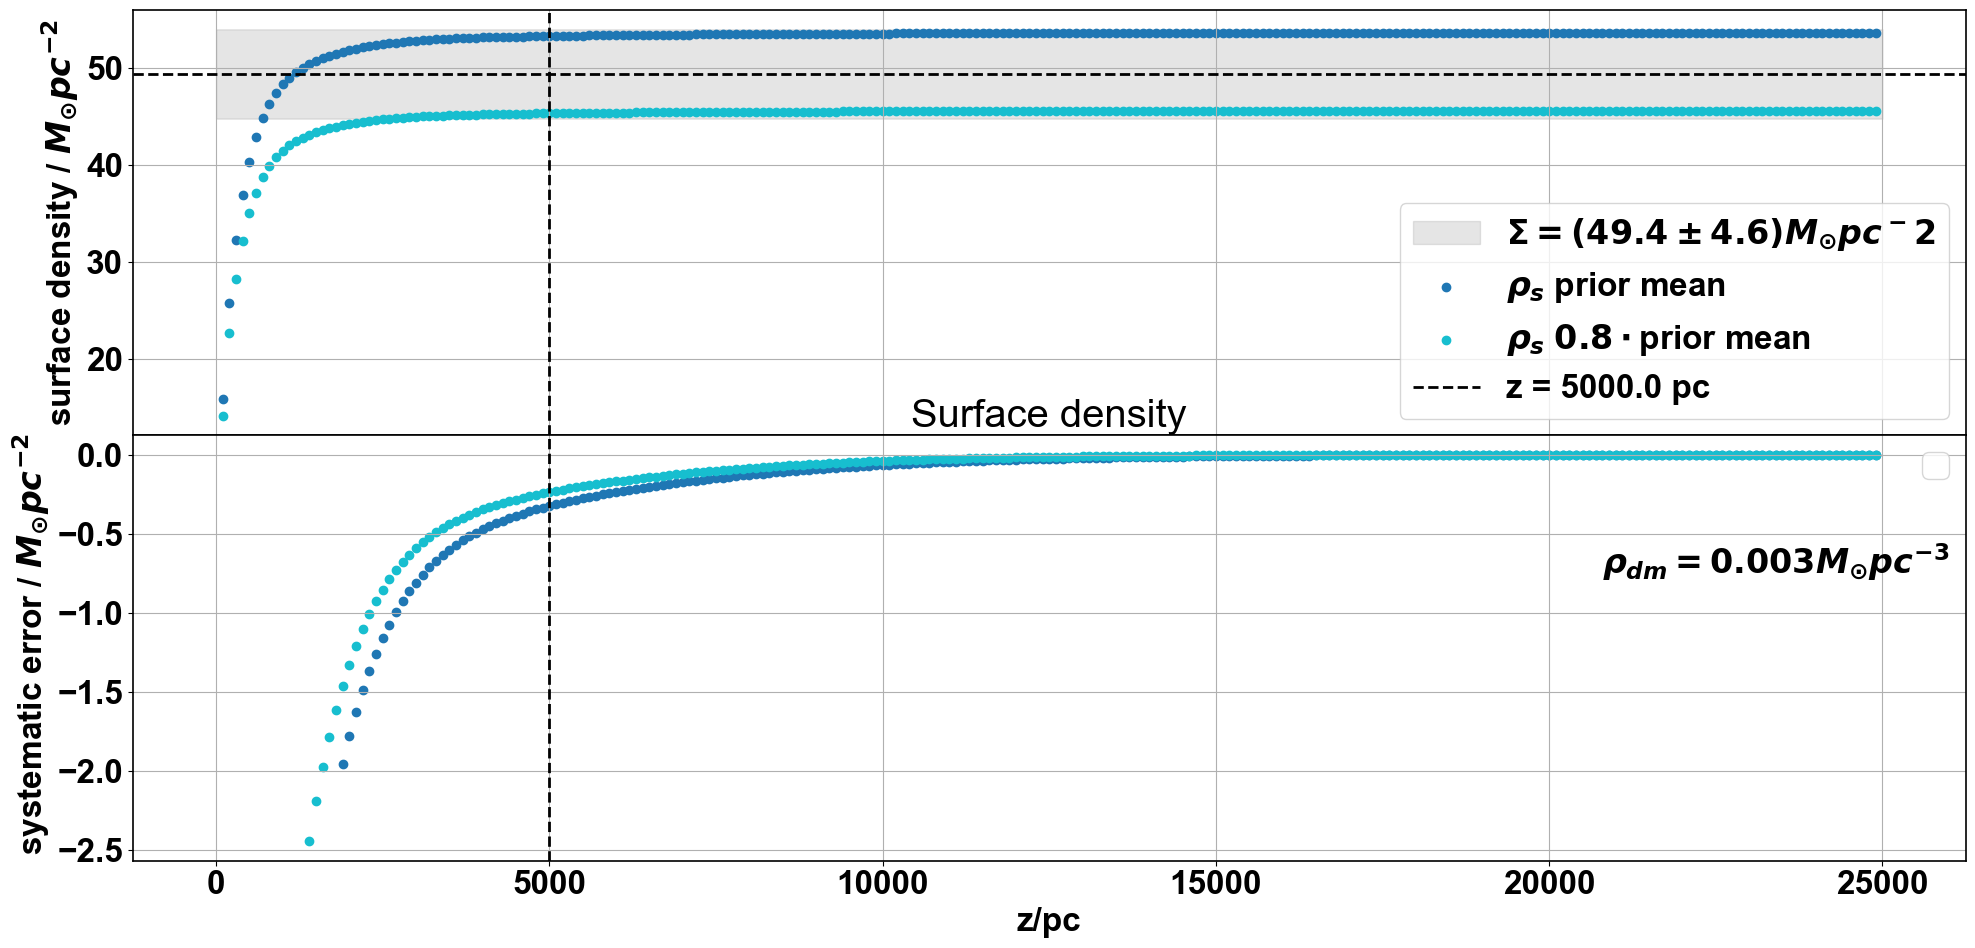

In [14]:
''' Testing surface density approximation'''
''' Domain'''
z1_ = 25000.
z3_ = 1800.
dz1_ = 100
dz3_ = 1
n1_ = int(z1_/dz1_+1)
n3_ = int(z3_/dz3_+1)

''' Forward Model '''
points = jnp.unique(jnp.append(jnp.linspace(0, z3_, n3_), jnp.linspace(0, z1_, n1_)))
wheres = [list(points).index(element) for element in jnp.unique(jnp.append(jnp.arange(100, z3_, 100), jnp.arange(z3_, z1_, 100)))]

# uz_paper, zs_paper = util.Solver_points(rho_dm, params, points)
# uz_paper2, zs_paper2 = util.Solver_points(rho_dm, 1.15*params, points)
# uz_SHM, zs_SHM = util.Solver_points(rho_dm_SHM, params, points)
# uz_SHM2, zs_SHM2 = util.Solver_points(rho_dm_SHM, 1.15*params, points)

def term(params, u):
    return jnp.sum(params[:,0]*jnp.exp(-u[0]/params[:,1]**2))

def surf_dens(term, where):
    return 2*jnp.sum(term[:where]*(points[1:where+1]-points[:where]))

# term_paper = jnp.array([term(params, u) for u in uz_paper])
# term_paper2 = jnp.array([term(1.15*params, u) for u in uz_paper2])
# term_SHM = jnp.array([term(params, u) for u in uz_SHM])
# term_SHM2 = jnp.array([term(1.15*params, u) for u in uz_SHM2])

# ''' Visualisation '''
# fig, ax = plt.subplots(2, figsize=(20,20), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Surface density')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('$\Phi / (km/s)^2$')
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel('$term$')

# ax[0].scatter(zs_paper, [u[0] for u in uz_paper], label='Paper')
# ax[0].scatter(zs_SHM, [u[0] for u in uz_SHM], label='SHM')

# ax[1].scatter(zs_paper, term_paper, label='Paper')
# ax[1].scatter(zs_SHM, term_SHM, label='SHM')

# ax[0].grid()
# ax[1].grid()
# ax[1].legend()
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)


# fig, ax = plt.subplots(2, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [1,1]})
# plt.title('Surface density')
# ax[0].set_xlabel('z/pc')
# ax[0].set_ylabel('surface density / $M_{\odot}pc^{-2}$')
# ax[1].set_xlabel('z/pc')
# ax[1].set_ylabel(' systematic error / $M_{\odot}pc^{-2}$')
# ax[0].axhline(49.4, color='black', linestyle='--')
# ax[0].fill_between(points, 49.4-4.6,49.4+4.6, color='gray', alpha=0.2, label=rf'$\Sigma = (49.4 \pm 4.6) M_{{\odot}}pc^{-2}$')

# x = jnp.array([points[where] for where in wheres])
# y_paper = jnp.array([surf_dens(term_paper, where) for where in wheres])
# y_paper2 = jnp.array([surf_dens(term_paper2, where) for where in wheres])
# y_SHM = jnp.array([surf_dens(term_SHM, where) for where in wheres])
# y_SHM2 = jnp.array([surf_dens(term_SHM2, where) for where in wheres])
# ax[0].scatter(x, y_paper, label='Paper [1]', marker='o', color='tab:blue')
# ax[0].scatter(x, y_paper2, label='Paper [1.15]', marker='o', color='tab:cyan')
# ax[0].scatter(x, y_SHM, label='SHM', marker='x', color='tab:orange')
# ax[0].scatter(x, y_SHM2, label='SHM [1.15]', marker='x', color='orange')

# i = 49
# ax[1].scatter(x[13:], y_paper[13:]-surf_dens(term_paper, wheres[-1]), marker='o', color='tab:blue')
# ax[1].scatter(x[13:], y_paper2[13:]-surf_dens(term_paper2, wheres[-1]), marker='o', color='tab:cyan')
# ax[1].scatter(x[20:], y_SHM[20:]-surf_dens(term_SHM, wheres[-1]), marker='x', color='tab:orange')
# ax[1].scatter(x[20:], y_SHM2[20:]-surf_dens(term_SHM2, wheres[-1]), marker='x', color='orange')
# ax[0].axvline(x[i], color='black', linestyle='--', label=f'z = {x[i]} pc')
# ax[1].axvline(x[i], color='black', linestyle='--')

# ax[0].grid()
# ax[1].grid(which='both')
# ax[0].legend()
# ax[1].legend()
# #ax[1].set_yscale('log')
# fig.tight_layout()
# fig.subplots_adjust(hspace=0.0)

# print( 2 * jnp.sum(term_paper[:-1] * (points[1:]-points[:-1])) )
# print( 2 * jnp.sum(term_SHM[:-1] * (points[1:]-points[:-1])) )
# print(49.4, '+-', 4.6)

uz_test, zs_test = util.Solver_points(0.003, params, points)
uz_test2, zs_test2 = util.Solver_points(0.003, 0.9*params, points)

term_test = jnp.array([term(params, u) for u in uz_test])
term_test2 = jnp.array([term(0.9*params, u) for u in uz_test2])

y_test = jnp.array([surf_dens(term_test, where) for where in wheres])
y_test2 = jnp.array([surf_dens(term_test2, where) for where in wheres])

fig, ax = plt.subplots(2, figsize=(20,10), sharex=True, gridspec_kw={'height_ratios': [1,1]})
plt.title('Surface density')
ax[0].set_xlabel('z/pc')
ax[0].set_ylabel('surface density / $M_{\odot}pc^{-2}$')
ax[1].set_xlabel('z/pc')
ax[1].set_ylabel(' systematic error / $M_{\odot}pc^{-2}$')
ax[0].axhline(49.4, color='black', linestyle='--')
ax[0].fill_between(points, 49.4-4.6,49.4+4.6, color='gray', alpha=0.2, label=rf'$\Sigma = (49.4 \pm 4.6) M_{{\odot}}pc^{-2}$')

x = jnp.array([points[where] for where in wheres])
plt.figtext(0.8, 0.4, rf'$\rho_{{dm}} = 0.003 M_{{\odot}}pc^{{-3}}$')
ax[0].scatter(x, y_test, label=rf'$\rho_{{s}}$ prior mean', marker='o', color='tab:blue')
ax[0].scatter(x, y_test2, label=rf'$\rho_{{s}}$ $0.8\cdot$prior mean', marker='o', color='tab:cyan')


i = 49
ax[1].scatter(x[18:], y_test[18:]-surf_dens(term_test, wheres[-1]), marker='o', color='tab:blue')
ax[1].scatter(x[13:], y_test2[13:]-surf_dens(term_test2, wheres[-1]), marker='o', color='tab:cyan')

ax[0].axvline(x[i], color='black', linestyle='--', label=f'z = {x[i]} pc')
ax[1].axvline(x[i], color='black', linestyle='--')

ax[0].grid()
ax[1].grid(which='both')
ax[0].legend()
ax[1].legend()
#ax[1].set_yscale('log')
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.savefig('../Plots/surface_density.png')

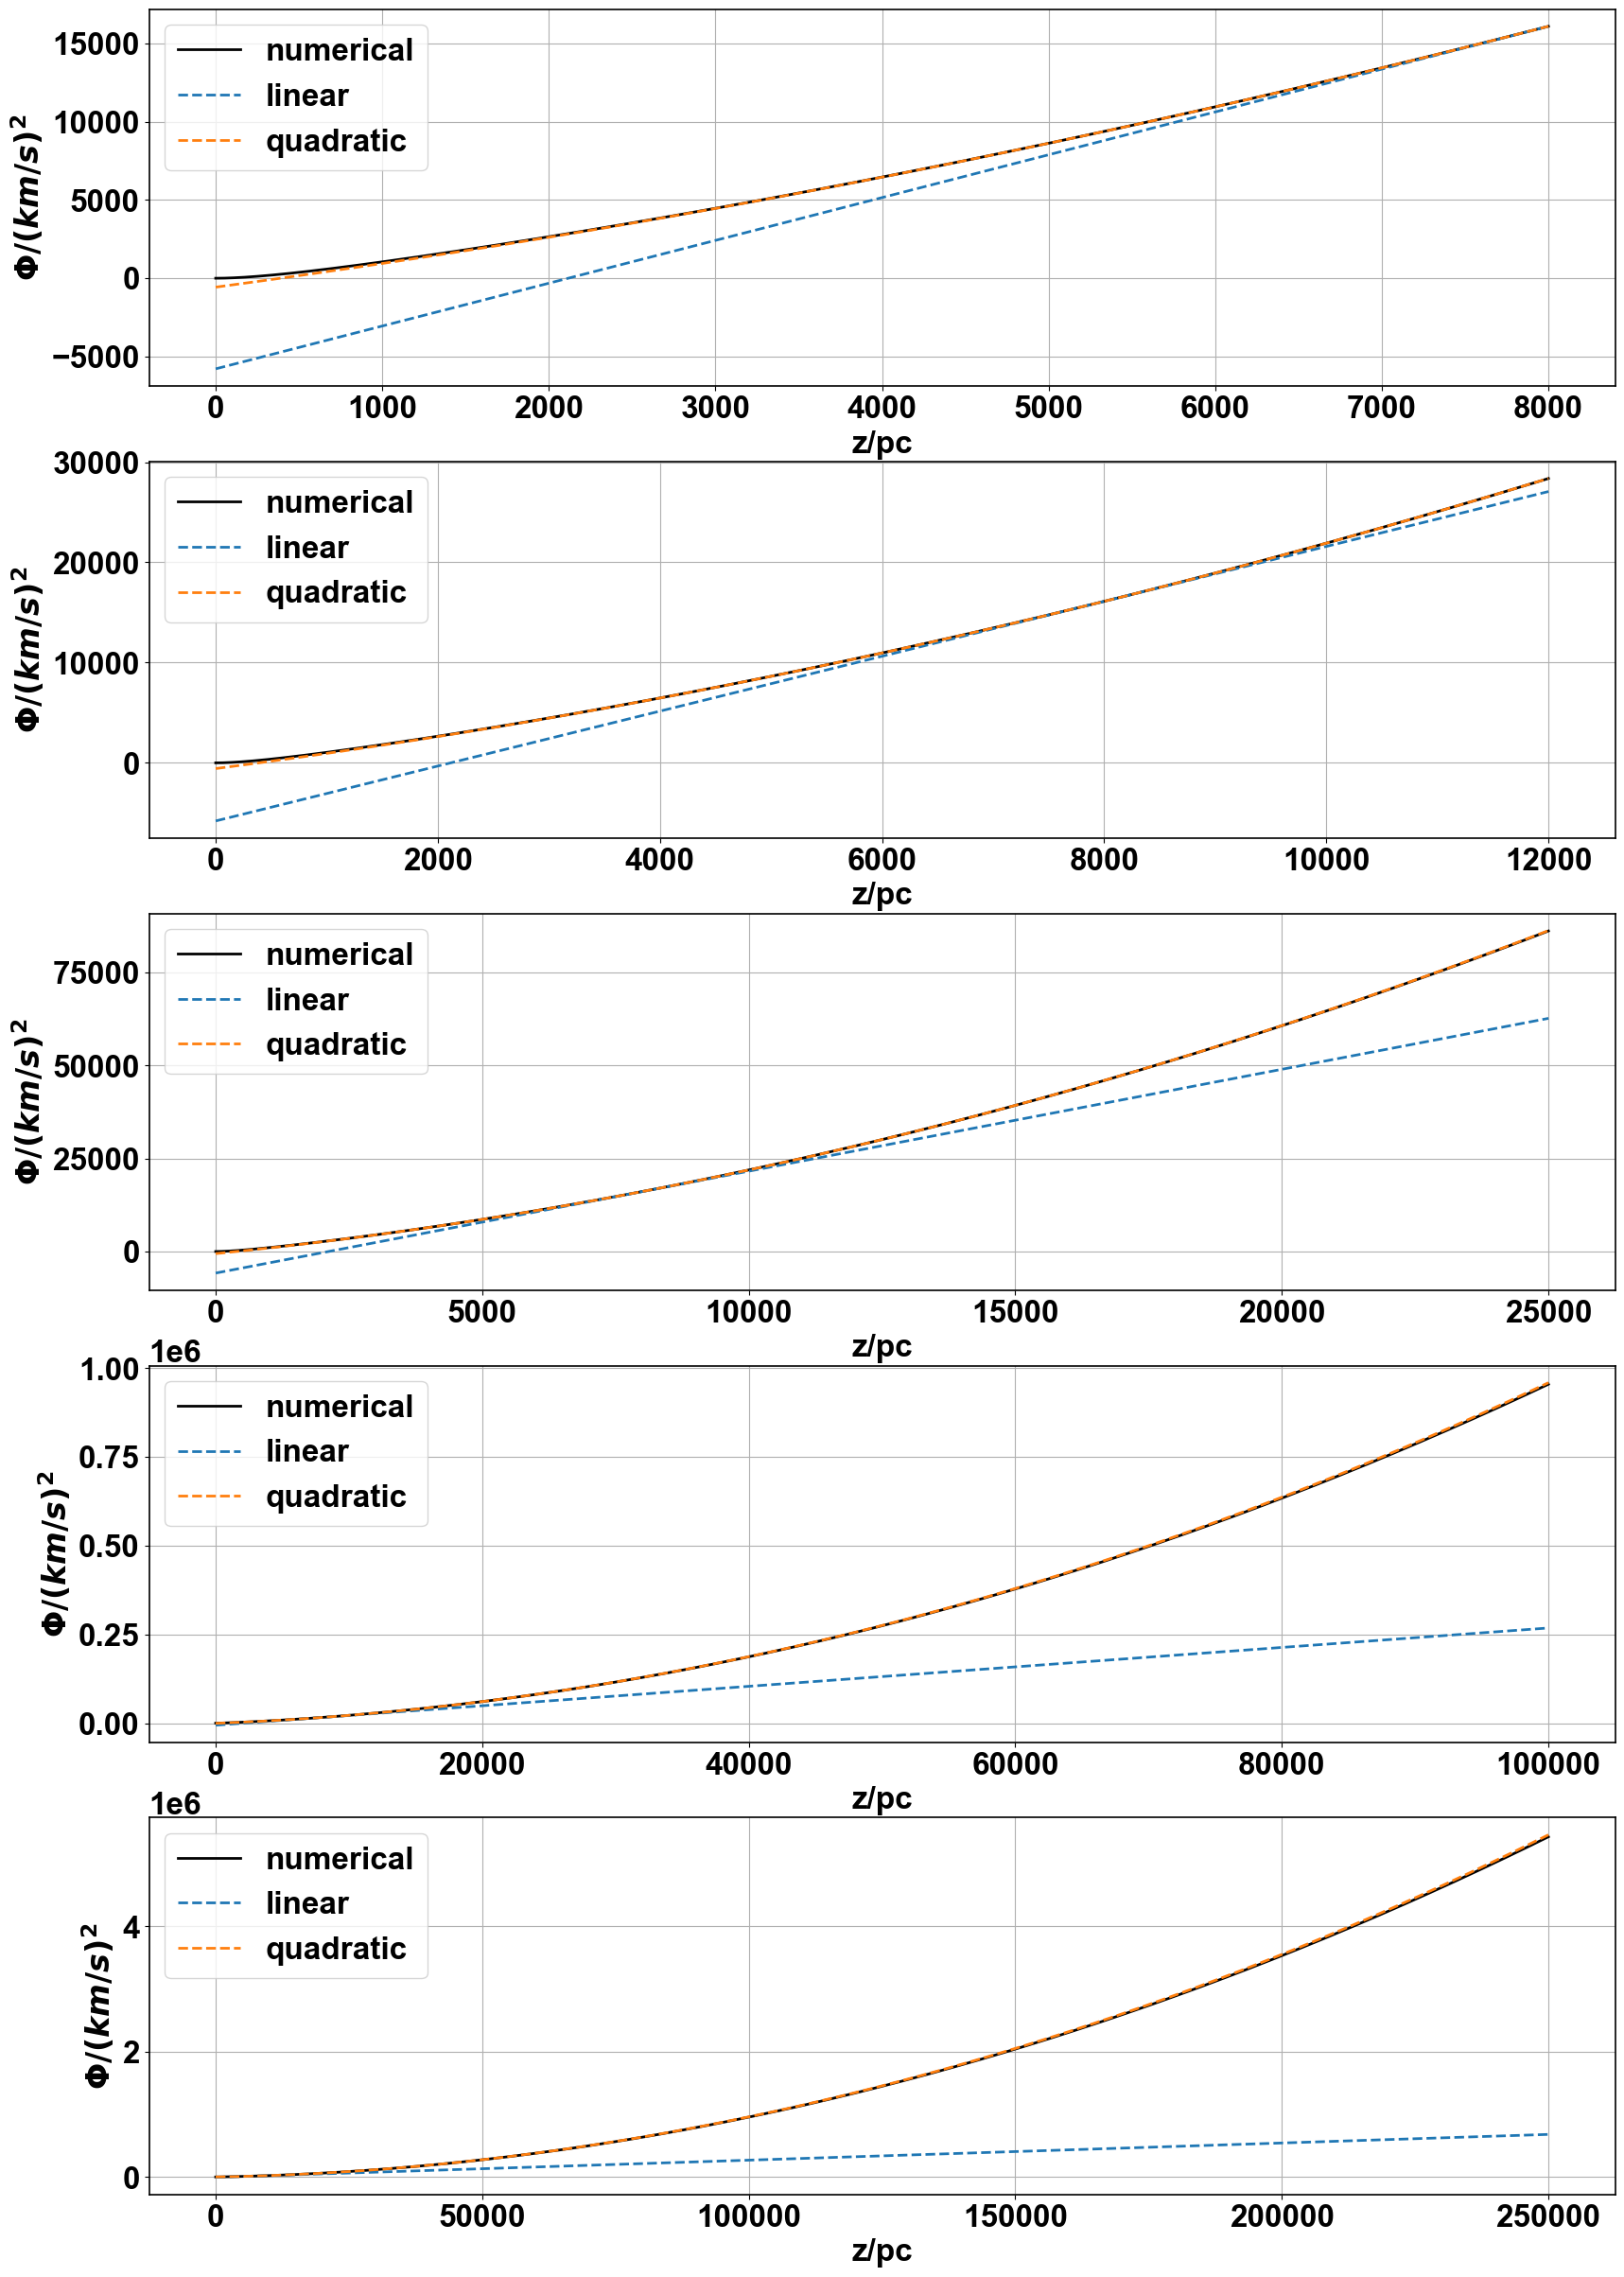

In [15]:
fig, axs = plt.subplots(5, figsize=(20,30), gridspec_kw={'height_ratios': [1,1,1,1,1]})
for ax, z1_long in zip(axs, jnp.array([8000, 12000, 25000, 100000, 250000])):
    uz_long, zs_long = util.diffraxDopri5(0.003, params, z1_long, int(z1_long)+1)
    ax.plot(zs_long, [u[0] for u in uz_long], label='numerical', color='black')

    lin = uz_long[8000,1]*(zs_long-zs_long[8000]) + uz_long[8000,0]
    ax.plot(zs_long, lin, label='linear', linestyle='--')
    sq = (uz_long[8000,1]-uz_long[7999,1])/(zs_long[8000]-zs_long[7999])/2 * (zs_long-zs_long[8000])**2 + uz_long[8000,1]*(zs_long-zs_long[8000]) + uz_long[8000,0]
    ax.plot(zs_long, sq, label='quadratic', linestyle='--')
    ax.legend()

    ax.set_xlabel('z/pc')
    ax.set_ylabel('$\Phi / (km/s)^2$')
    ax.grid()
plt.savefig('../Plots/surface_density_long.png')
plt.show()

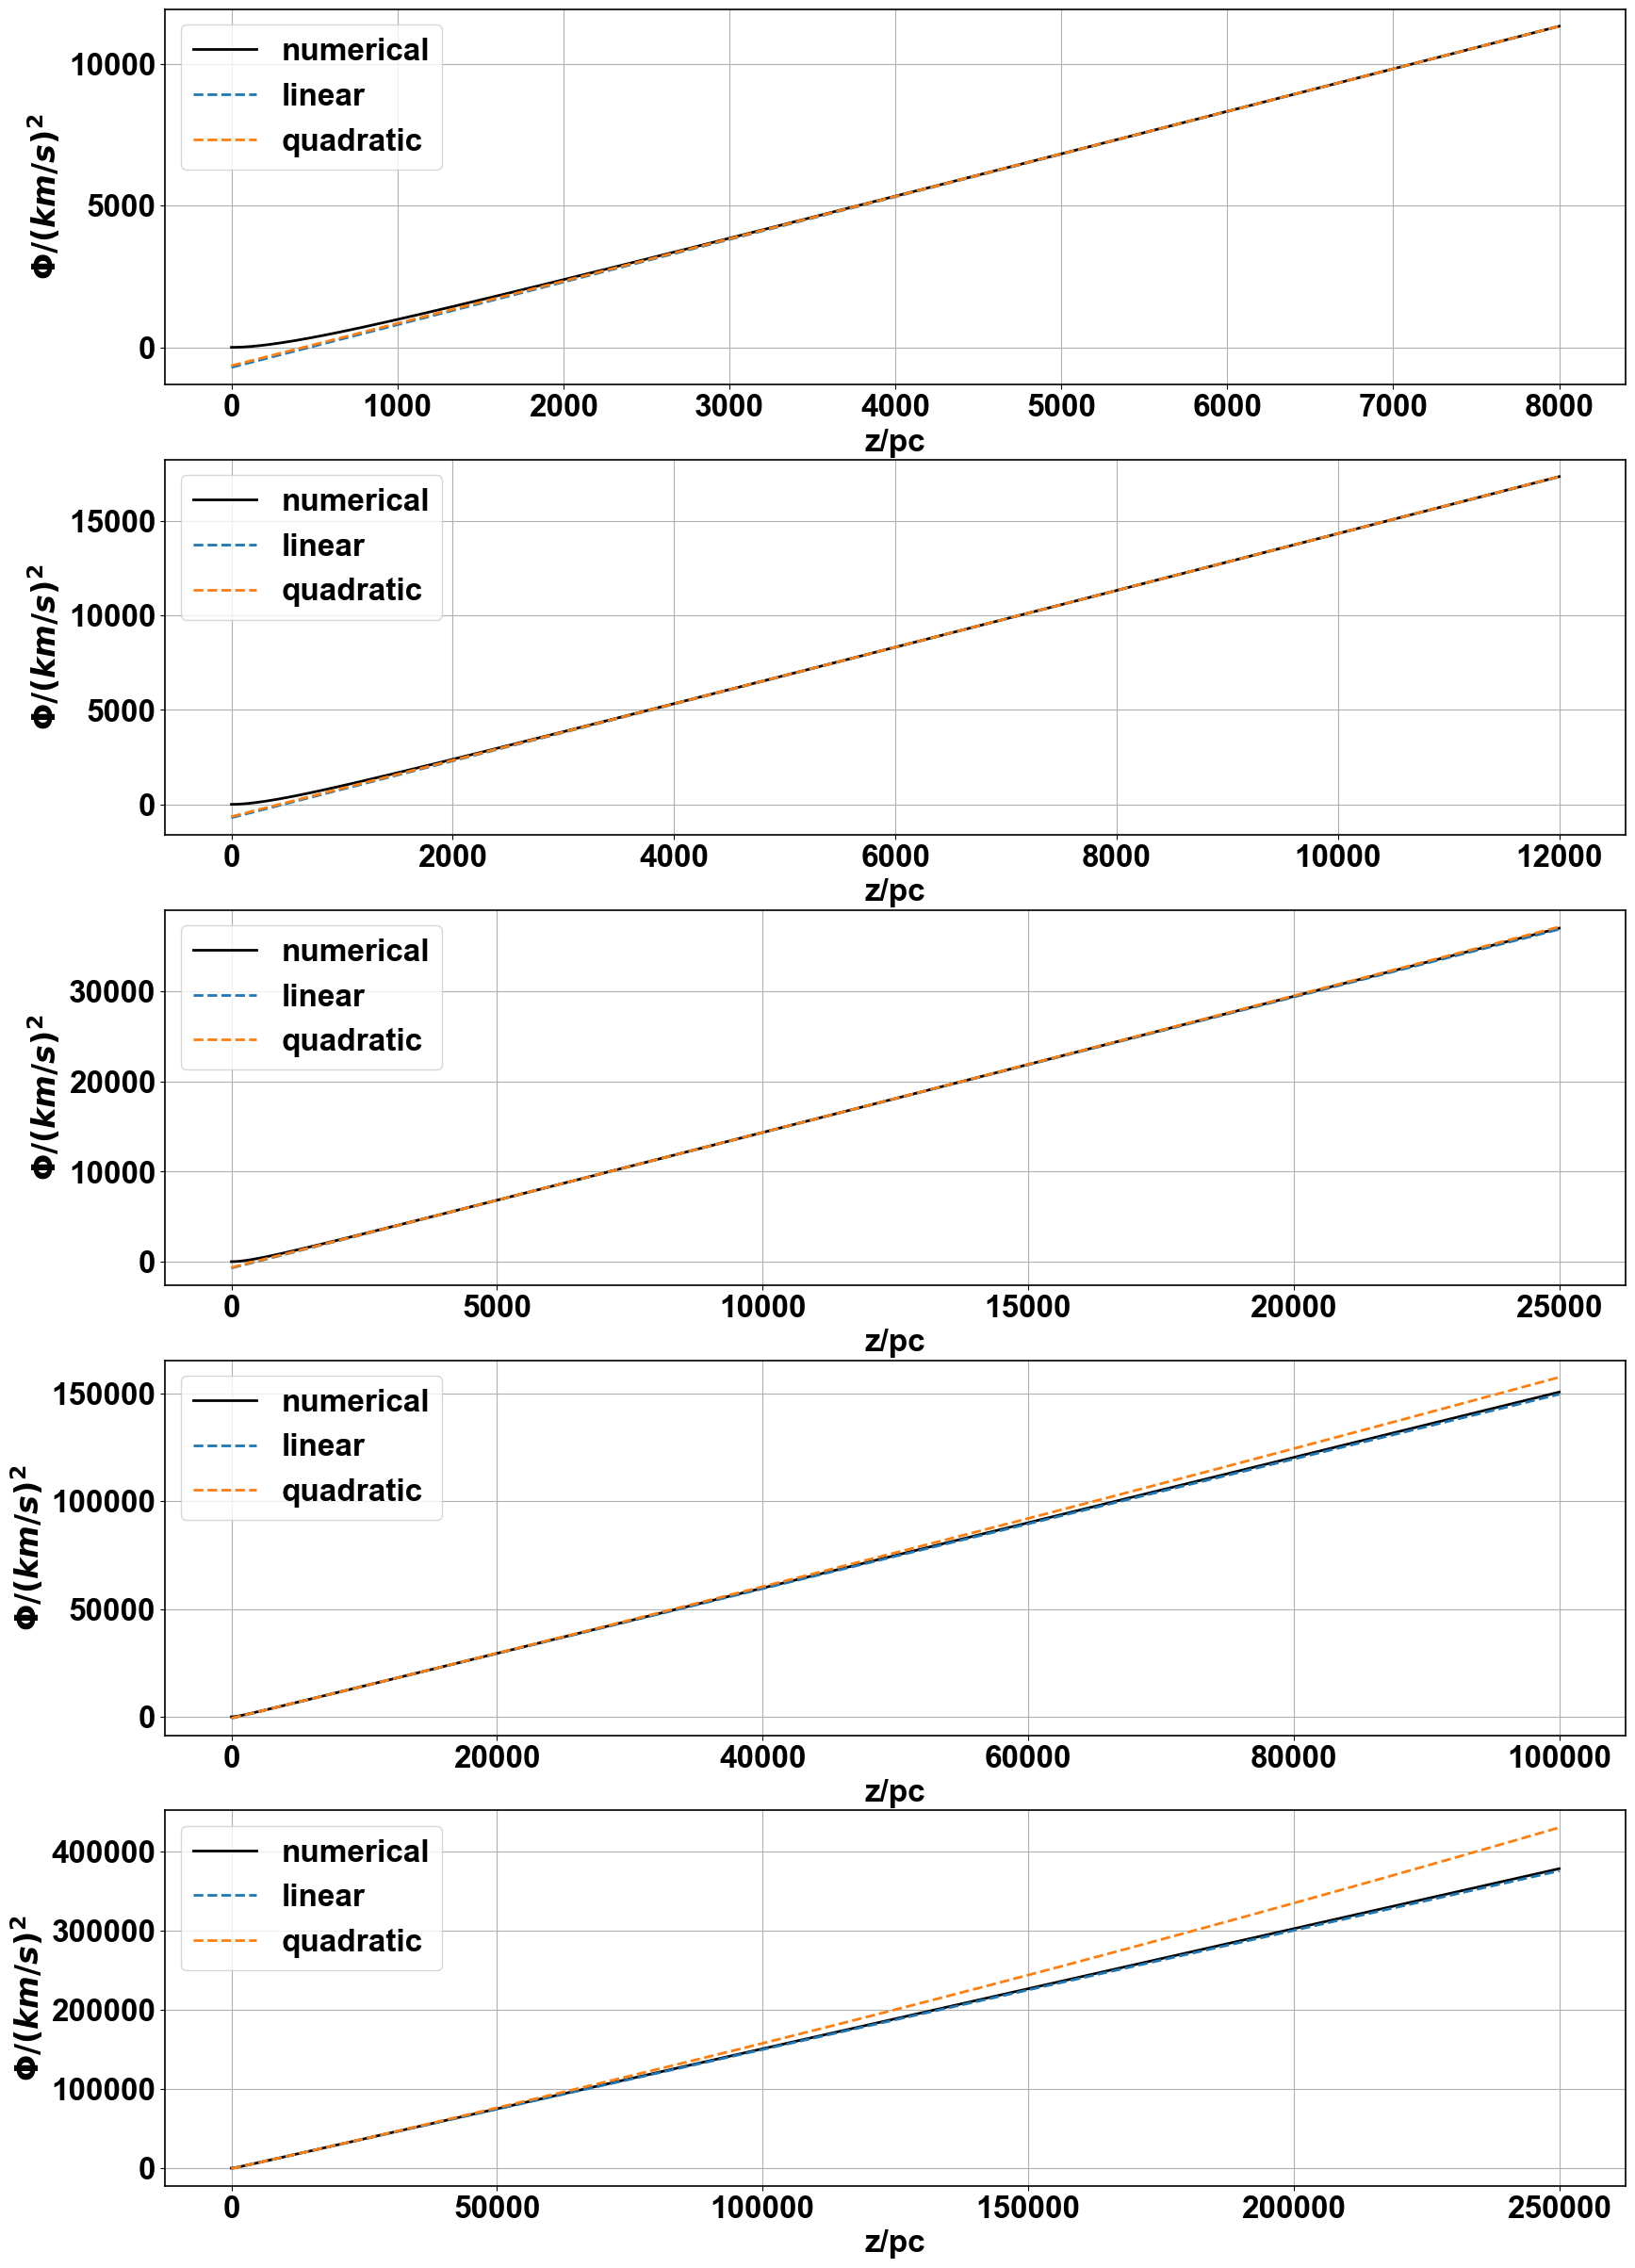

In [16]:
fig, axs = plt.subplots(5, figsize=(20,30), gridspec_kw={'height_ratios': [1,1,1,1,1]})
for ax, z1_long in zip(axs, jnp.array([8000, 12000, 25000, 100000, 250000])):
    uz_long, zs_long = util.diffraxDopri5(0.0, params, z1_long, int(z1_long)+1)
    ax.plot(zs_long, [u[0] for u in uz_long], label='numerical', color='black')

    lin = uz_long[8000,1]*(zs_long-zs_long[8000]) + uz_long[8000,0]
    ax.plot(zs_long, lin, label='linear', linestyle='--')
    sq = (uz_long[8000,1]-uz_long[7999,1])/(zs_long[8000]-zs_long[7999])/2 * (zs_long-zs_long[8000])**2 + uz_long[8000,1]*(zs_long-zs_long[8000]) + uz_long[8000,0]
    ax.plot(zs_long, sq, label='quadratic', linestyle='--')
    ax.legend()

    ax.set_xlabel('z/pc')
    ax.set_ylabel('$\Phi / (km/s)^2$')
    ax.grid()
plt.savefig('../Plots/surface_density_long_norho_dm.png')
plt.show()